## setup

In [98]:
import pandas as pd 
import textdescriptives as td
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np
import statsmodels.formula.api as smf

df_full = pd.read_parquet('../data/TEXT/processed/full_story_surface_metrics.parquet')
df_inter = pd.read_parquet('../data/TEXT/processed/interaction_level_surface_metrics.parquet')


### Plotting AI vs User surface metrics (Full story)

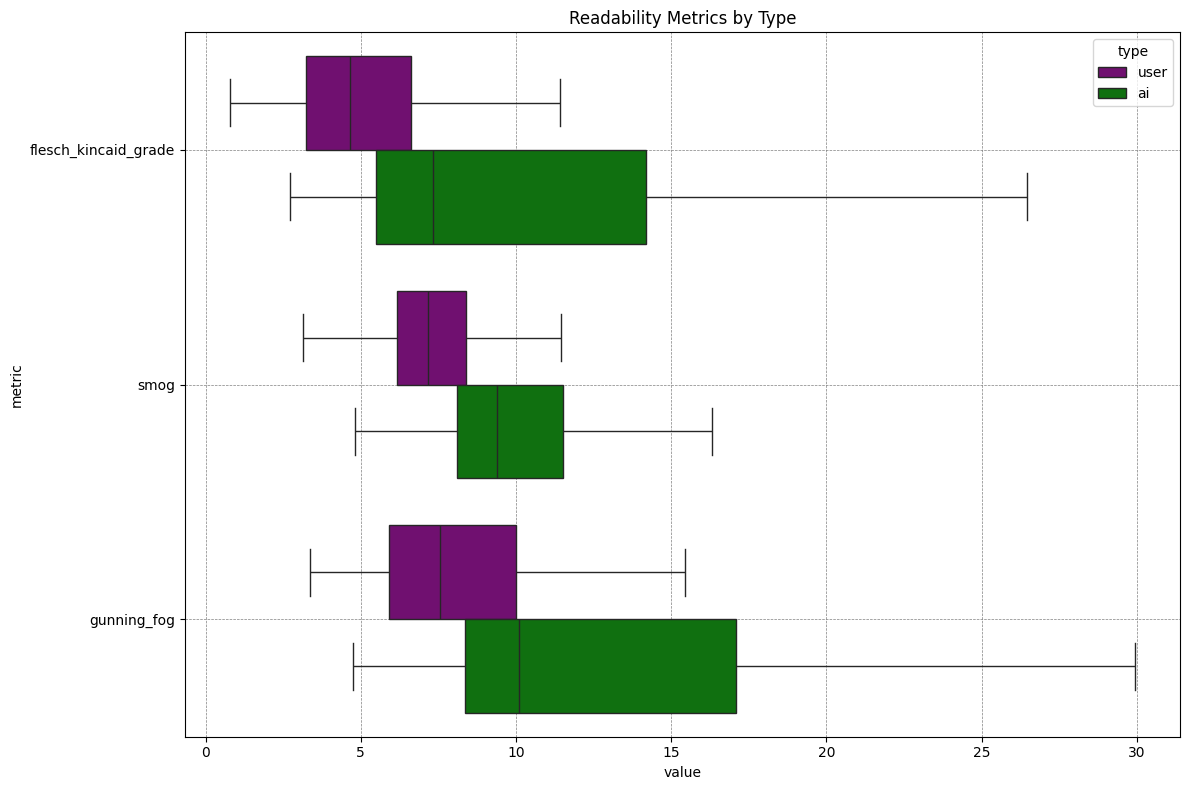

In [2]:
readability = ['flesch_kincaid_grade', 'smog',
       'gunning_fog']

df_long = df_full.melt(id_vars='type', value_vars=readability, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # readability metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h',         # horizontal orientation
    showfliers = False
)
plt.title('Readability Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


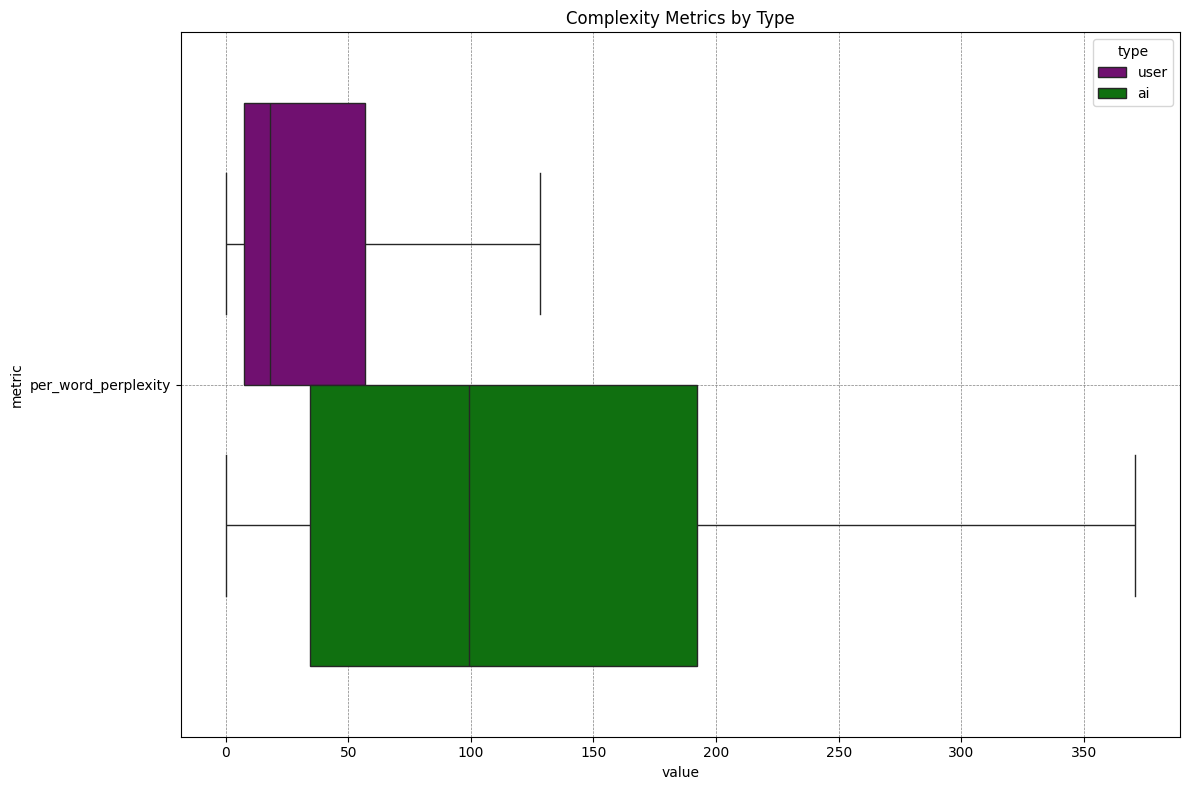

In [3]:
# complexity = ['entropy', 'perplexity']
complexity = ['per_word_perplexity']
df_long = df_full.melt(id_vars='type', value_vars=complexity, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h',         # horizontal orientation
    showfliers=False
)


plt.title('Complexity Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


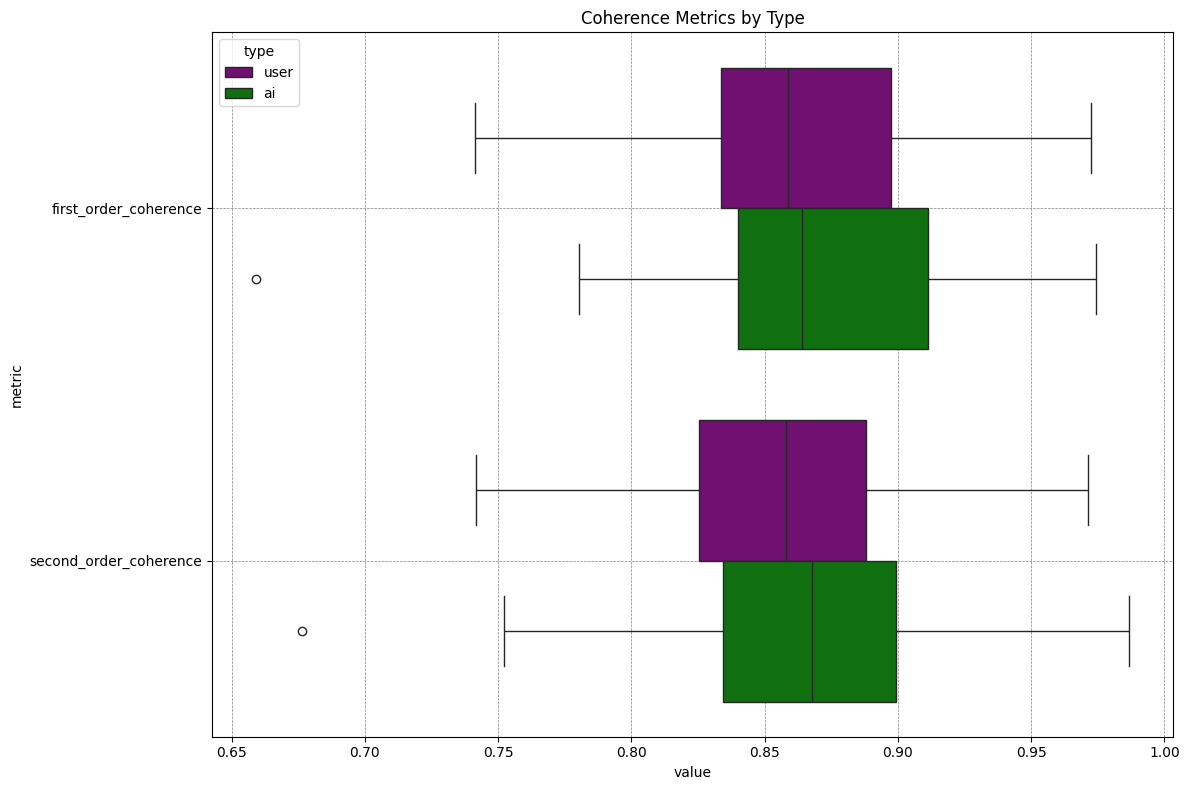

In [4]:
coherence = ['first_order_coherence', 'second_order_coherence']
df_long = df_full.melt(id_vars='type', value_vars=coherence, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Coherence Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

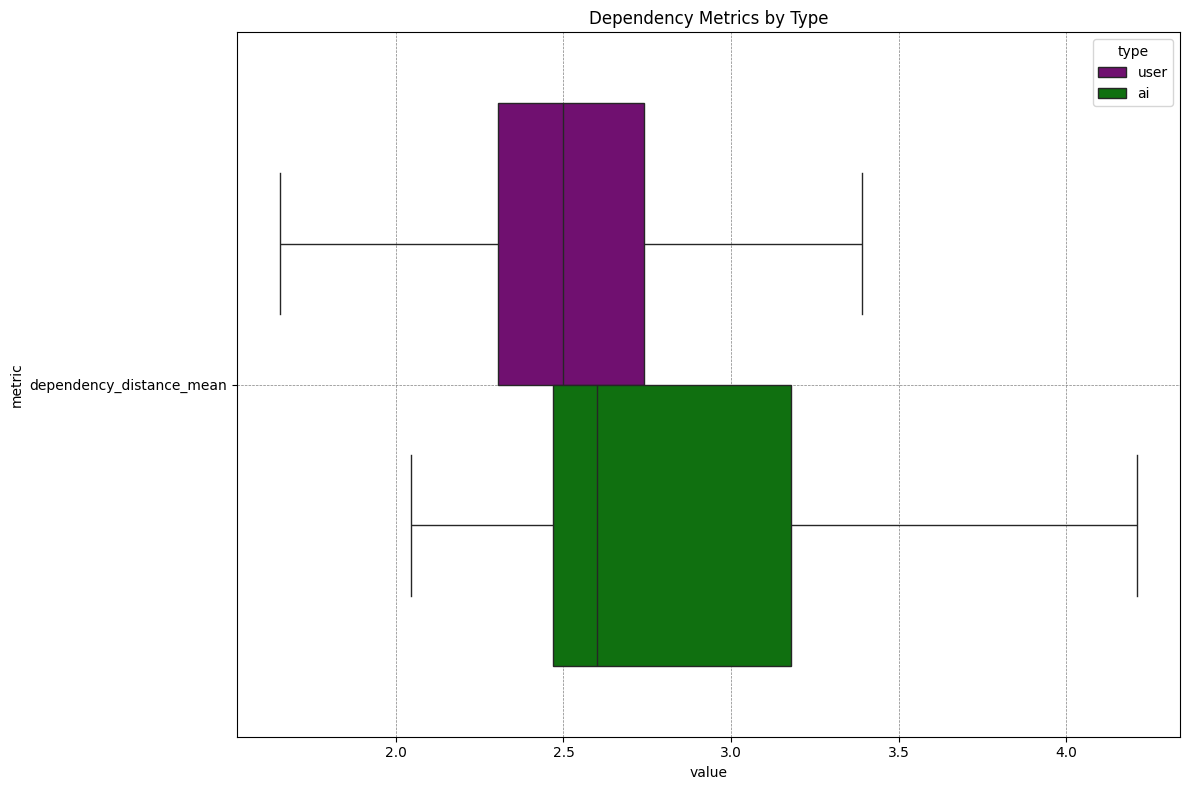

In [5]:
dependency = ['dependency_distance_mean']
df_long = df_full.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h',         # horizontal orientation
    showfliers=False
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

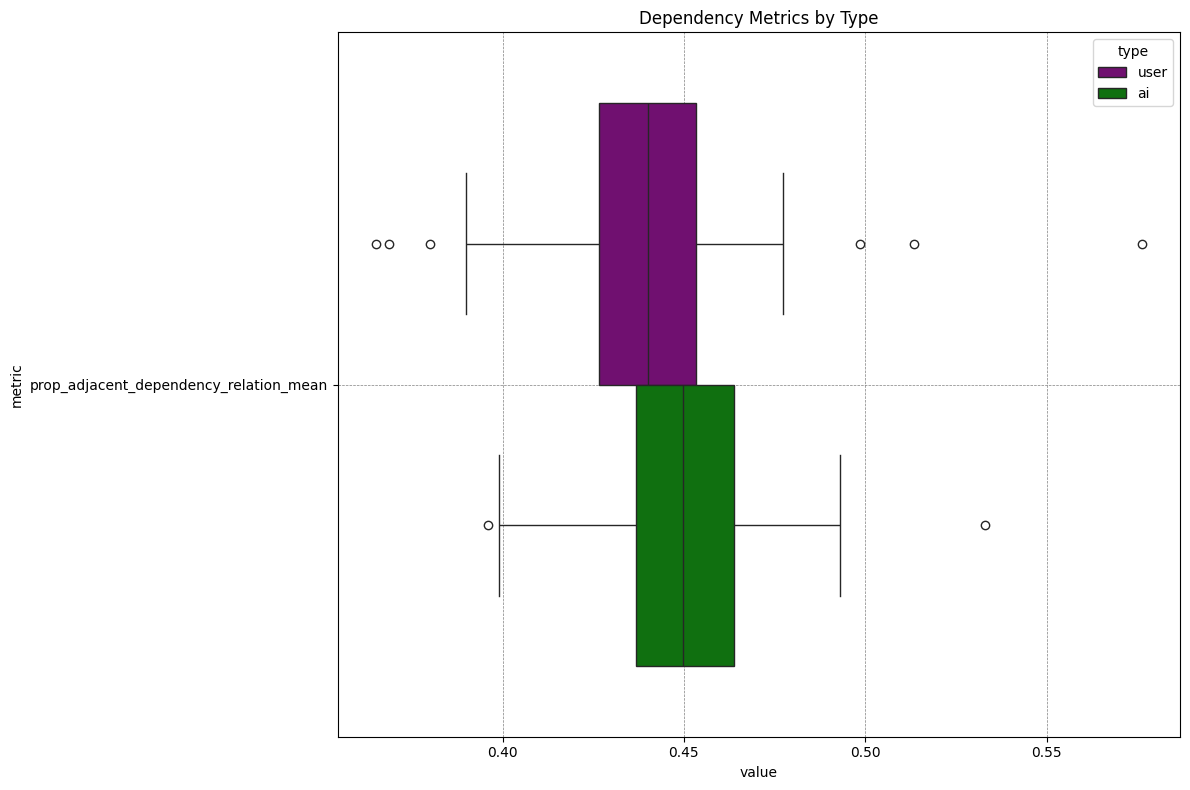

In [6]:
dependency = ['prop_adjacent_dependency_relation_mean']
df_long = df_full.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

In [7]:
pos_names = {
'ADJ': 'adjective',
'ADP': 'adposition',
'ADV': 'adverb',
'AUX': 'auxiliary',
'CCONJ': 'coordinating conjunction',
'DET': 'determiner',
'INTJ': 'interjection',
'NOUN': 'noun',
'NUM': 'numeral',
'PART': 'particle',
'PRON': 'pronoun',
'PROPN': 'proper noun',
'PUNCT': 'punctuation',
'SCONJ': 'subordinating conjunction',
'SYM': 'symbol',
'VERB': 'verb',
'X': 'other',
}

In [8]:
metrics = [col for col in df.columns if col.startswith('pos_')]

# Compute group stats
group_means = df.groupby('type')[metrics].mean().T
group_sds = df.groupby('type')[metrics].std().T
group_ns = df['type'].value_counts()

# Standard error of the difference: sqrt(s1²/n1 + s2²/n2)
se_diff = np.sqrt(
    (group_sds['ai']**2 / group_ns['ai']) +
    (group_sds['user']**2 / group_ns['user'])
)

# Difference in means
group_means['diff'] = group_means['ai'] - group_means['user']
group_means['se_diff'] = se_diff

# Sort for display
subset = group_means.sort_values('diff', ascending=False)
subset = subset.rename(index = lambda col: pos_names.get(col.split('_')[-1], col).capitalize())

# --- Plot ---
plt.figure(figsize=(8, max(4, len(subset)*0.35)))
colors = subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')


plt.barh(
    subset.index,
    subset['diff'],
    xerr=subset['se_diff'],
    color=colors,
    # ecolor=colors,          # match bar color
    capsize=4,
    alpha=0.8
)

plt.axvline(0, color='black', linewidth=1)
plt.title("AI–User Mean Differences in Part-of-Speech Proportions")
plt.xlabel("Difference (AI - User) ± SE")
plt.ylabel("POS Tag")

legend_elements = [
    Patch(facecolor='purple', label='AI higher'),
    Patch(facecolor='green', label='User higher')
]

plt.legend(handles=legend_elements, title="Difference Direction")

plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

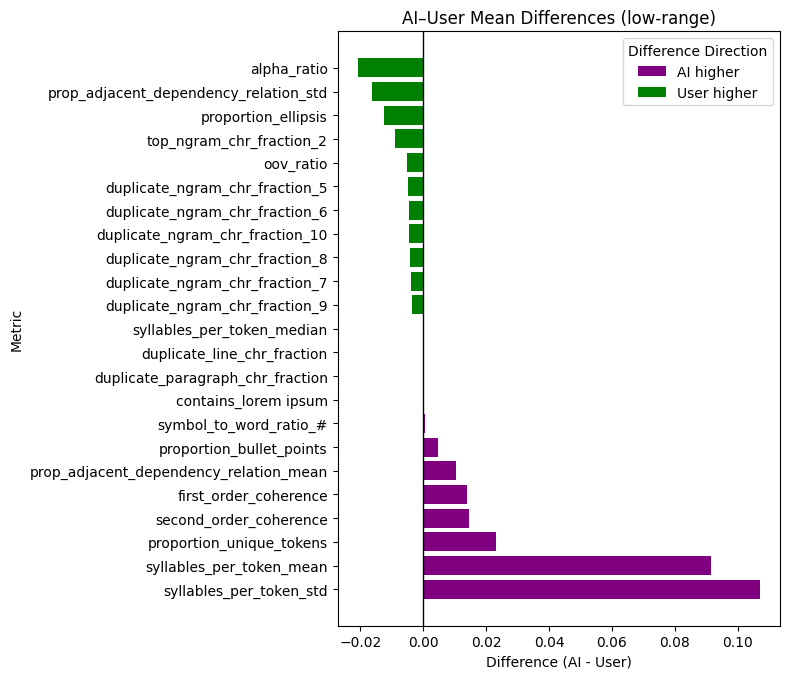

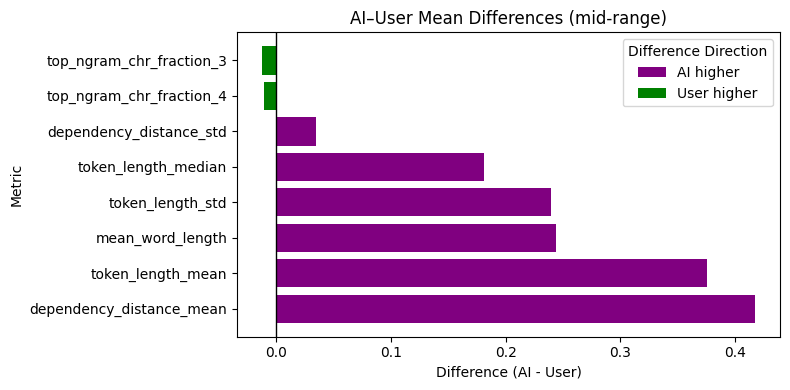

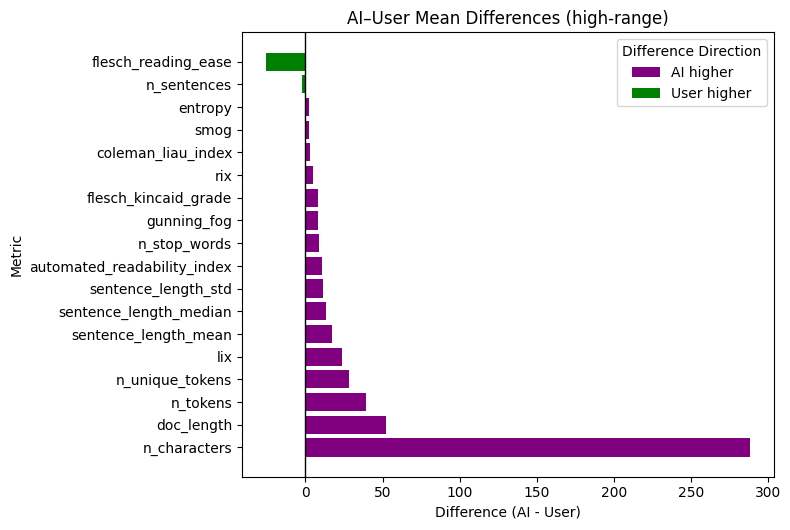

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Setup ---
df_numeric = df.select_dtypes('number')
metrics = [col for col in df_numeric.columns if not col.startswith('pos_') and col != 'perplexity' and col != 'per_word_perplexity']

# Compute mean per type
group_means = df.groupby('type')[metrics].mean().T
group_means['diff'] = group_means['ai'] - group_means['user']

# Compute ranges for grouping
min_vals = df_numeric.min()
max_vals = df_numeric.max()
ranges = max_vals - min_vals

# Define thresholds (tune if needed)
low_thr, mid_thr = 1, 10  # <1 small fractions, 1–10 mid, >10 high-range metrics

# Assign each metric to a scale group
scale_group = pd.cut(ranges, 
                     bins=[-np.inf, low_thr, mid_thr, np.inf], 
                     labels=['low-range', 'mid-range', 'high-range'])

group_means['scale_group'] = scale_group

# --- Plot each scale group separately ---
for group in ['low-range', 'mid-range', 'high-range']:
    subset = group_means[group_means['scale_group'] == group].sort_values('diff', ascending=False)
    if subset.empty:
        continue

    plt.figure(figsize=(8, max(4, len(subset)*0.3)))
    plt.barh(
        subset.index,
        subset['diff'],
        color=subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')
    )
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f"AI–User Mean Differences ({group})")
    plt.xlabel("Difference (AI - User)")
    plt.ylabel("Metric")
        
    legend_elements = [
        Patch(facecolor='purple', label='AI higher'),
        Patch(facecolor='green', label='User higher')
    ]

    plt.legend(handles=legend_elements, title="Difference Direction")
    plt.tight_layout()
    plt.show()


#### z-scored

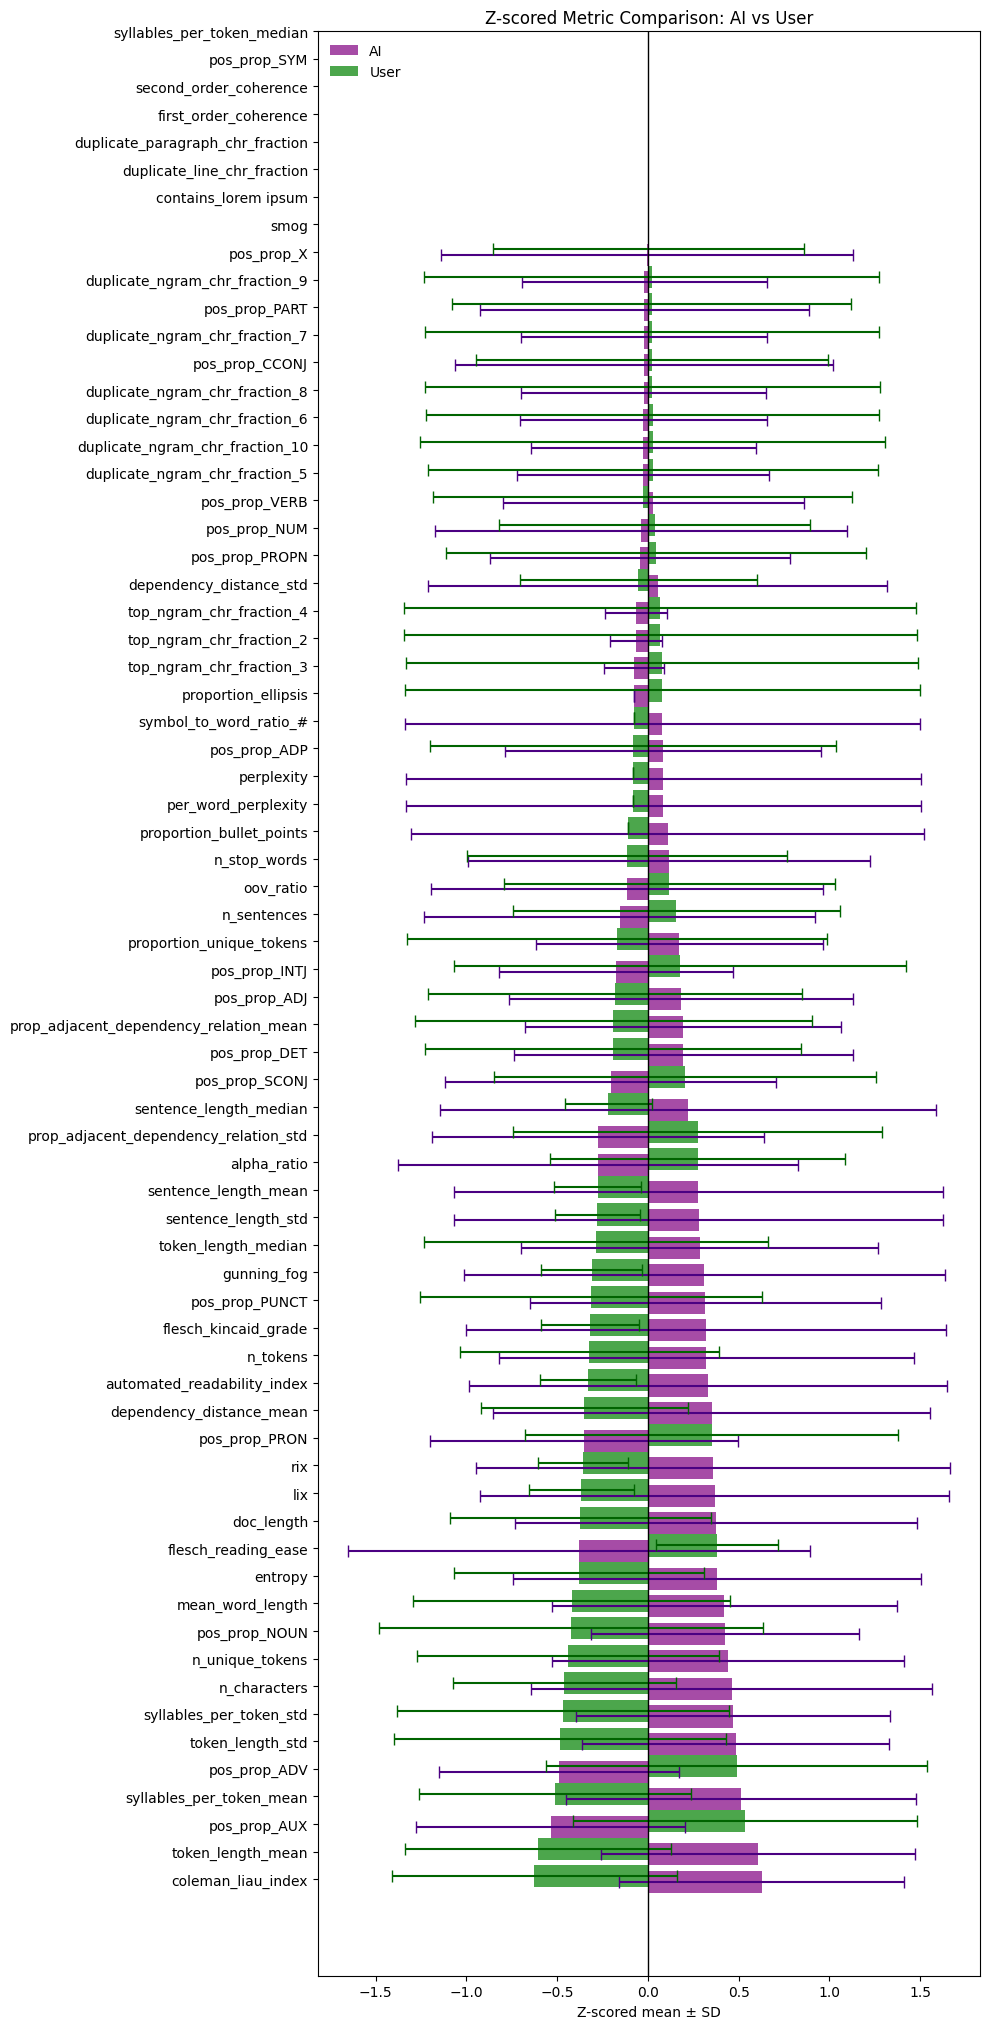

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# --- Z-score numeric metrics ---
df_numeric = df.select_dtypes('number')
metrics = df_numeric.columns
df_z = df_numeric.apply(zscore)
df_z['type'] = df['type']

# --- Compute means & sds ---
group_means = df_z.groupby('type')[metrics].mean().T
group_sds   = df_z.groupby('type')[metrics].std().T
group_means['diff'] = group_means['ai'] - group_means['user']

# --- Sort by absolute difference ---
order = group_means['diff'].abs().sort_values(ascending=False).index
x = np.arange(len(order))
width = 0.2

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, max(5, len(metrics)*0.3)))

# AI bars with purple error bars
ax.barh(x - width/2, group_means.loc[order, 'ai'],
        xerr=group_sds.loc[order, 'ai'],
        label='AI',
        color='purple', alpha=0.7, capsize=4, ecolor='indigo')

# User bars with green error bars
ax.barh(x + width/2, group_means.loc[order, 'user'],
        xerr=group_sds.loc[order, 'user'],
        label='User',
        color='green', alpha=0.7, capsize=4, ecolor='darkgreen',)

# Cosmetic tweaks
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(x)
ax.set_yticklabels(order)
ax.set_xlabel("Z-scored mean ± SD")
ax.set_title("Z-scored Metric Comparison: AI vs User")
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


### Interaction level analysis

In [9]:
pos_names = {
'ADJ': 'adjective',
'ADP': 'adposition',
'ADV': 'adverb',
'AUX': 'auxiliary',
'CCONJ': 'coordinating conjunction',
'DET': 'determiner',
'INTJ': 'interjection',
'NOUN': 'noun',
'NUM': 'numeral',
'PART': 'particle',
'PRON': 'pronoun',
'PROPN': 'proper noun',
'PUNCT': 'punctuation',
'SCONJ': 'subordinating conjunction',
'SYM': 'symbol',
'VERB': 'verb',
'X': 'other',
}

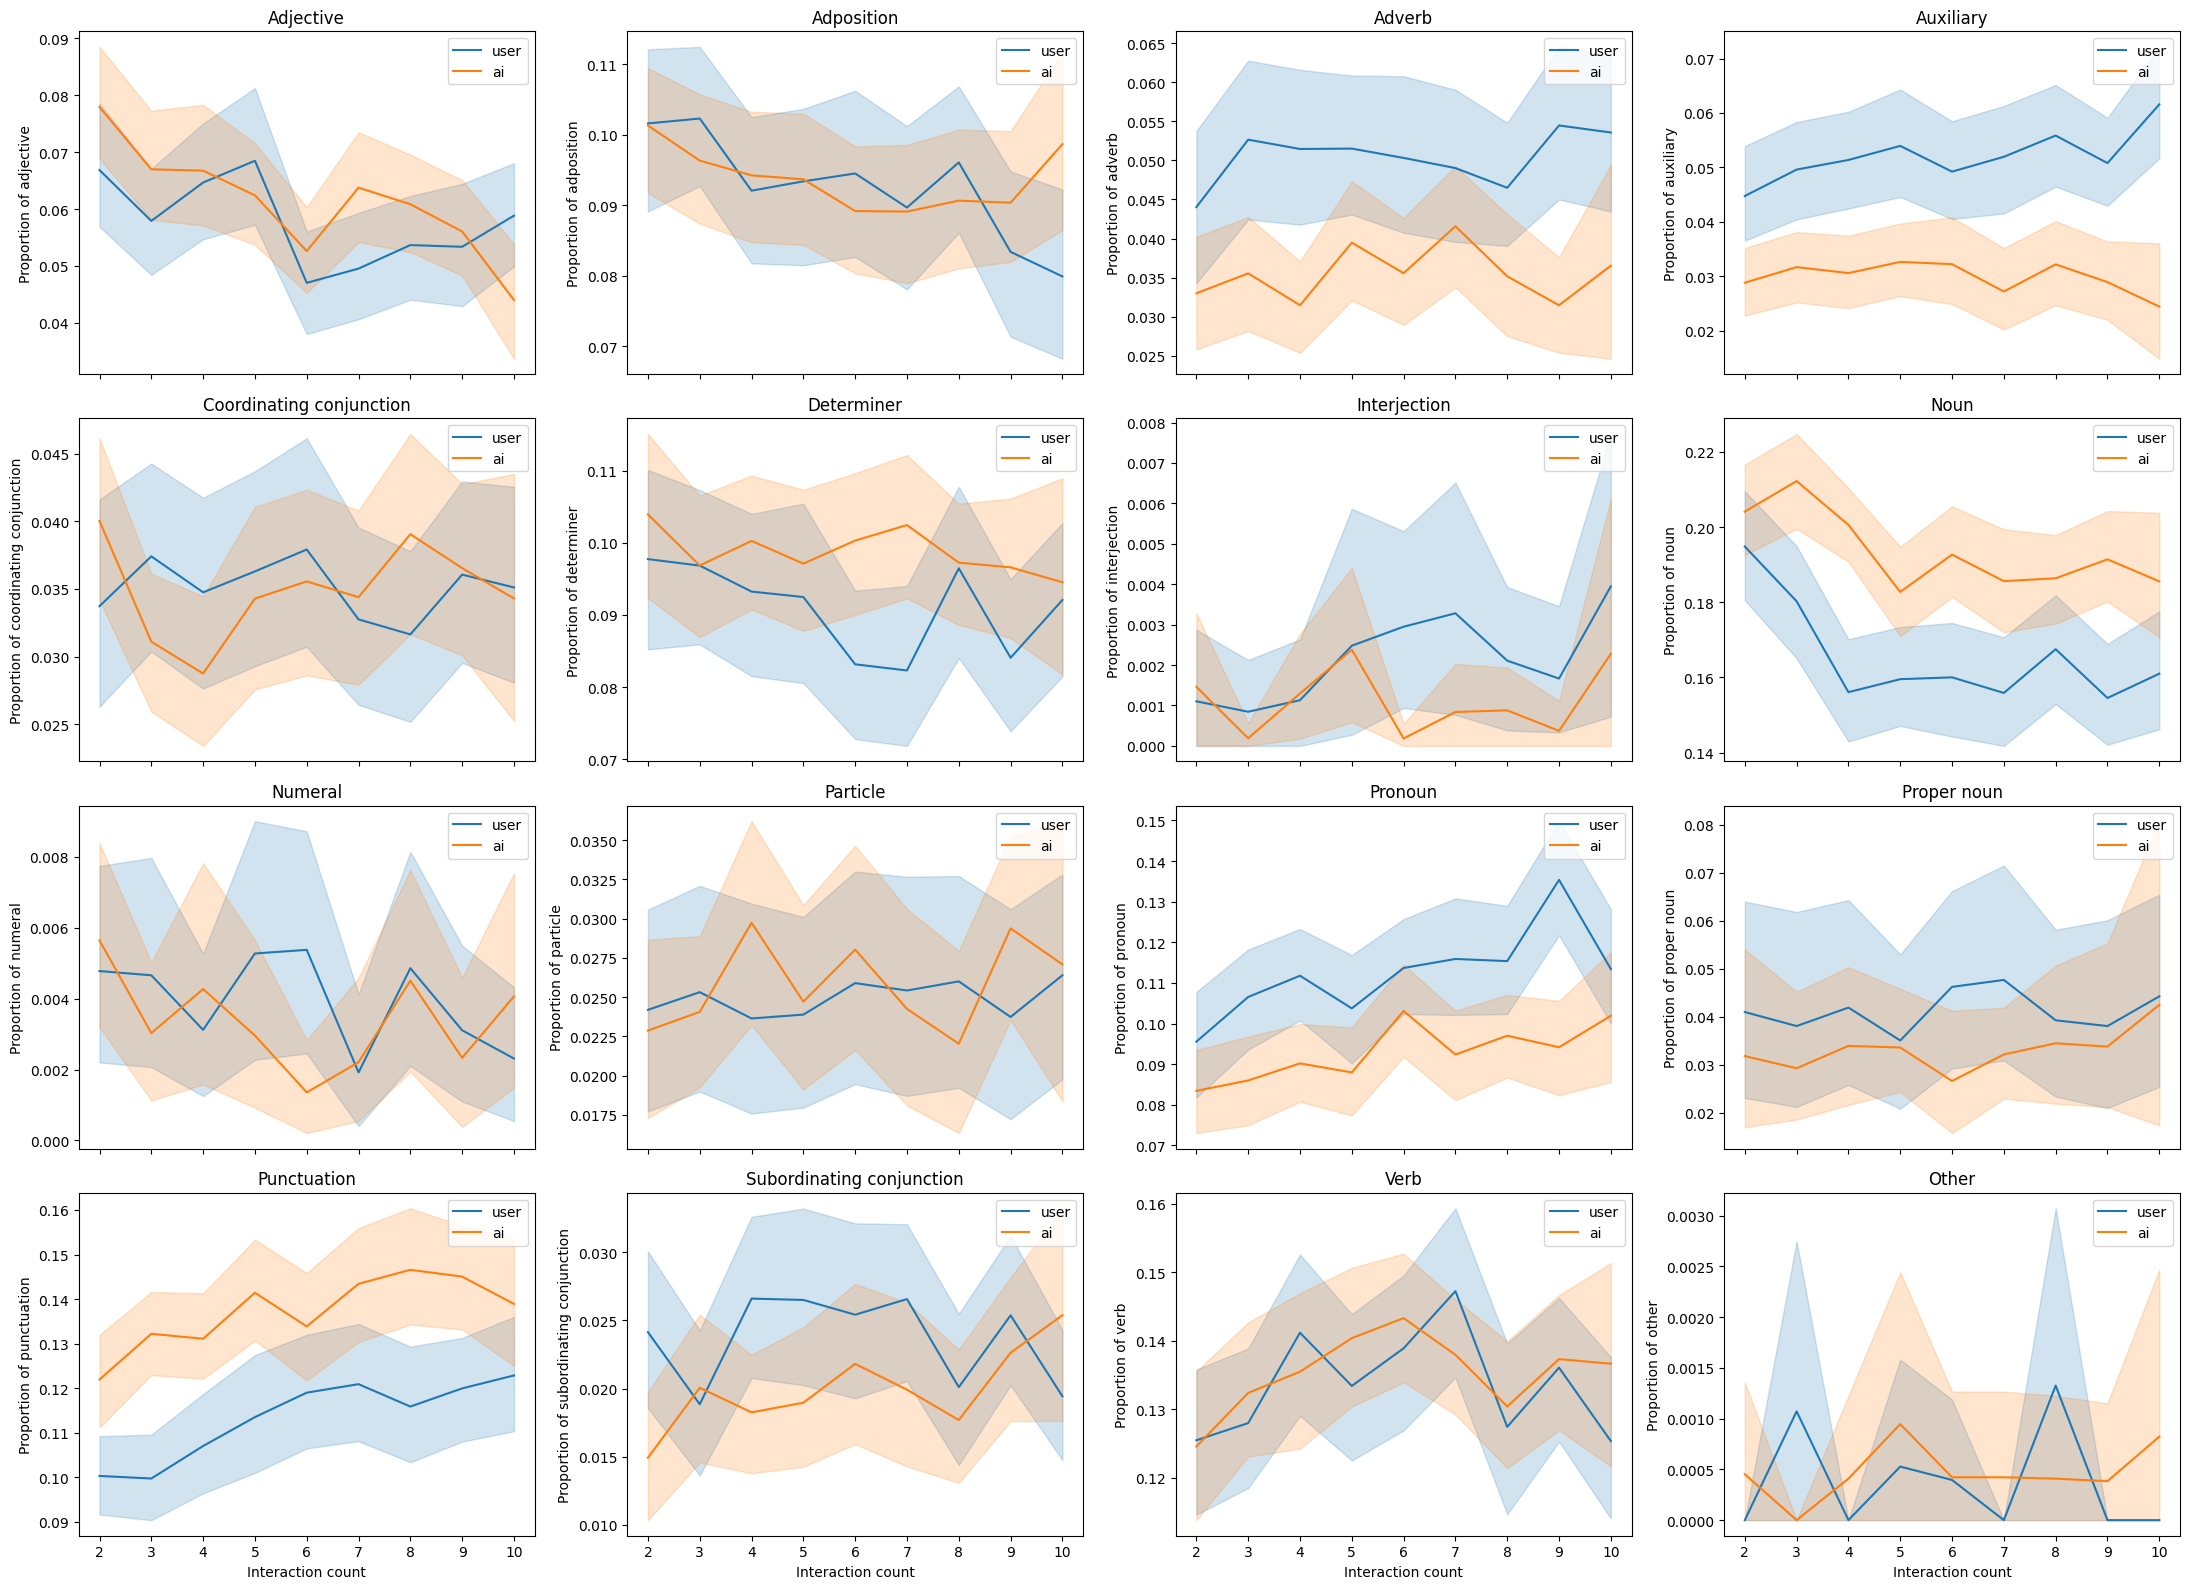

In [143]:
import warnings # To suppress some warnings
 
# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

df = df_inter.copy()
df = df[df['interaction_count'] > 1]

metrics = [col for col in df.columns if col.startswith('pos_') and col != 'pos_prop_SYM']

pos_names = {
    'ADJ': 'adjective',
    'ADP': 'adposition',
    'ADV': 'adverb',
    'AUX': 'auxiliary',
    'CCONJ': 'coordinating conjunction',
    'DET': 'determiner',
    'INTJ': 'interjection',
    'NOUN': 'noun',
    'NUM': 'numeral',
    'PART': 'particle',
    'PRON': 'pronoun',
    'PROPN': 'proper noun',
    'PUNCT': 'punctuation',
    'SCONJ': 'subordinating conjunction',
    'SYM': 'symbol',
    'VERB': 'verb',
    'X': 'other',
}

# sort metrics for consistent layout
metrics = sorted(metrics)

n = len(metrics)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 4), sharex=True)
axes = axes.flatten()

for ax, m in zip(axes, metrics):
    tag = m.replace("pos_prop_", "")
    p = pos_names.get(tag, tag)

    sns.lineplot(data=df, x=df["interaction_count"], y=m, hue="type", ax=ax)
    ax.set_title(p.capitalize())
    ax.set_ylabel(f"Proportion of {p}")
    ax.set_xlabel(f"Interaction count")
    ax.legend()

# remove unused axes if any
for ax in axes[len(metrics):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [67]:
import warnings # To suppress some warnings
 
def plot_interaction_descriptives(df = df_inter, metrics=None, starter=None): 
    # Suppress the specific FutureWarning
    warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
    if starter: 
        starter = starter
        df = df[df['starter'] == starter].copy()
        if starter == 'ai': 
            df = df[df['interaction_count'] > 1]
            
    
    ex_cols = df_inter.select_dtypes(exclude=["float", "int"]).columns.to_list()
    # df['type'] = df_inter['type']
    
    # sort metrics for consistent layout
    metrics = sorted([m for m in metrics if m not in ex_cols])

    n = len(metrics)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharex=True)
    axes = axes.flatten()
    fig.suptitle(f'{starter.upper()} starter', fontweight='semibold')

    for ax, m in zip(axes, metrics):

        sns.lineplot(data=df, x=df["interaction_count"], y=m, hue="type", ax=ax)
        ax.set_title(f"{" ".join([word.capitalize() for word in m.split('_')])} Across Interactions")
        ax.legend()

    # remove unused axes if any
    for ax in axes[len(metrics):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


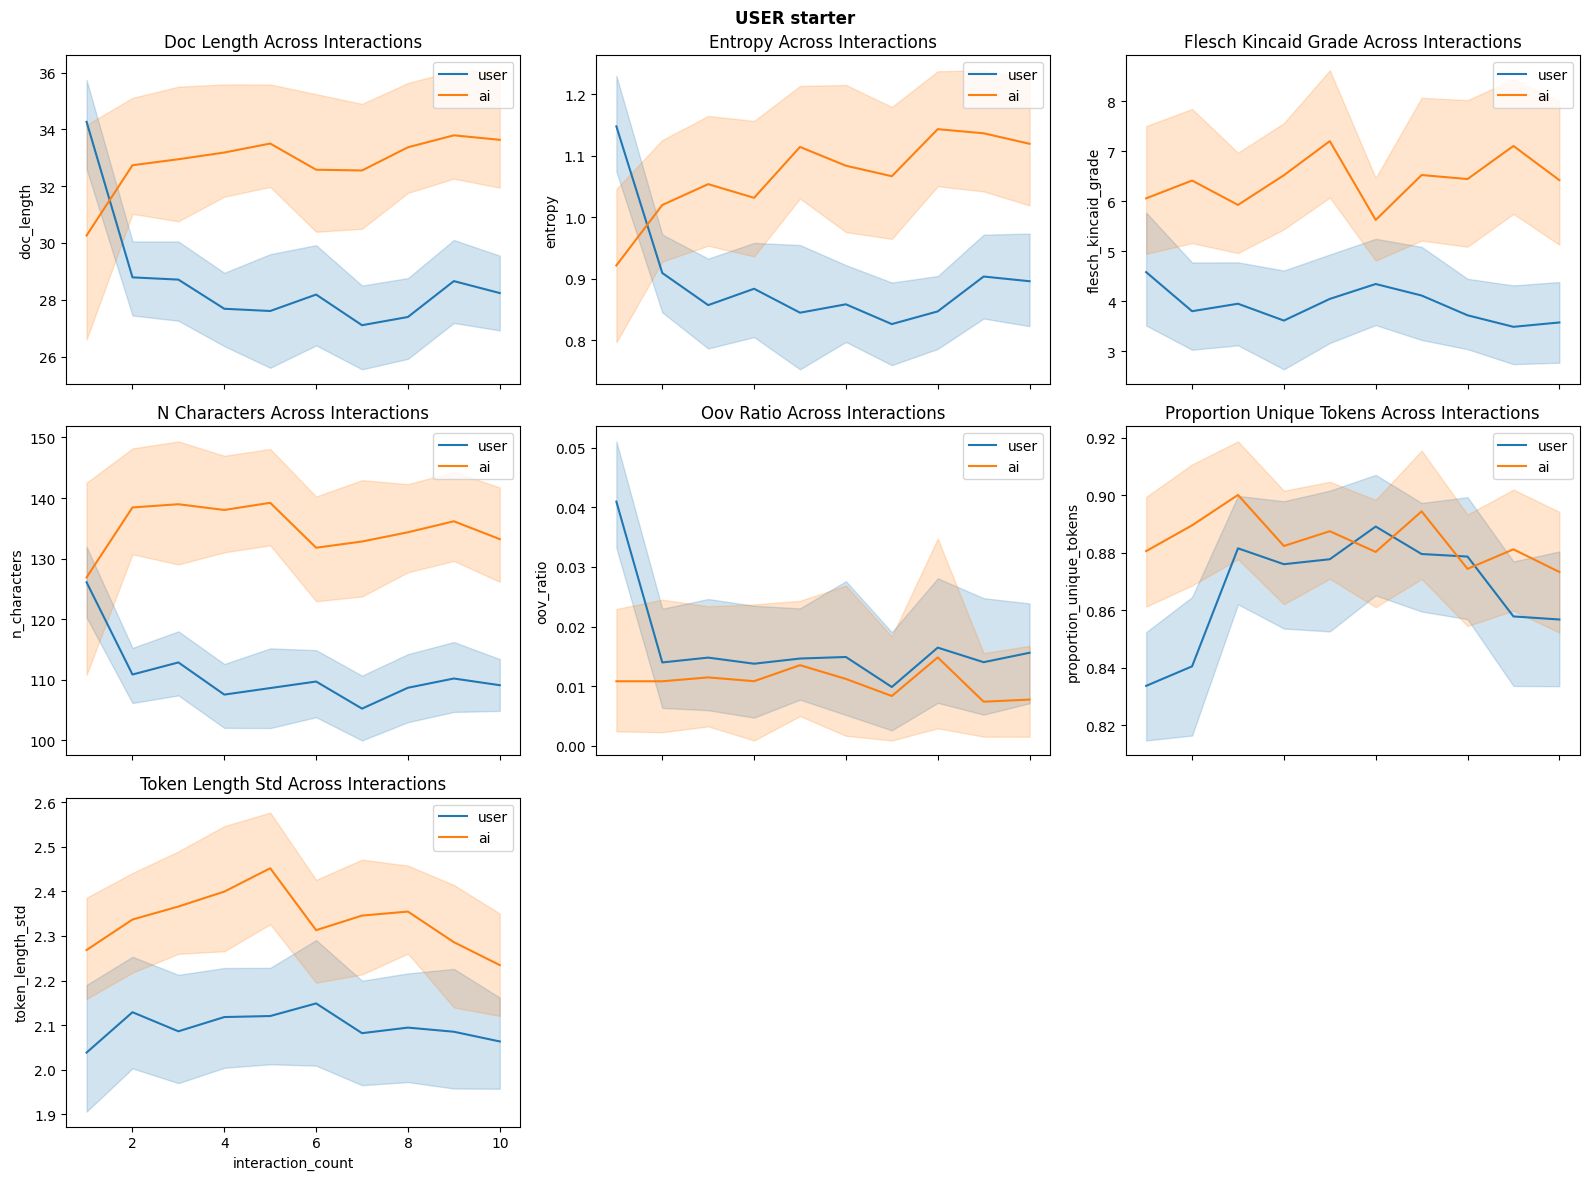

In [56]:
metrics = ['flesch_kincaid_grade', 'doc_length', 
'entropy', 
'n_characters', 
'oov_ratio', 
'proportion_unique_tokens', 
'token_length_std']

plot_interaction_descriptives(df=df_inter, metrics=metrics, starter='user')

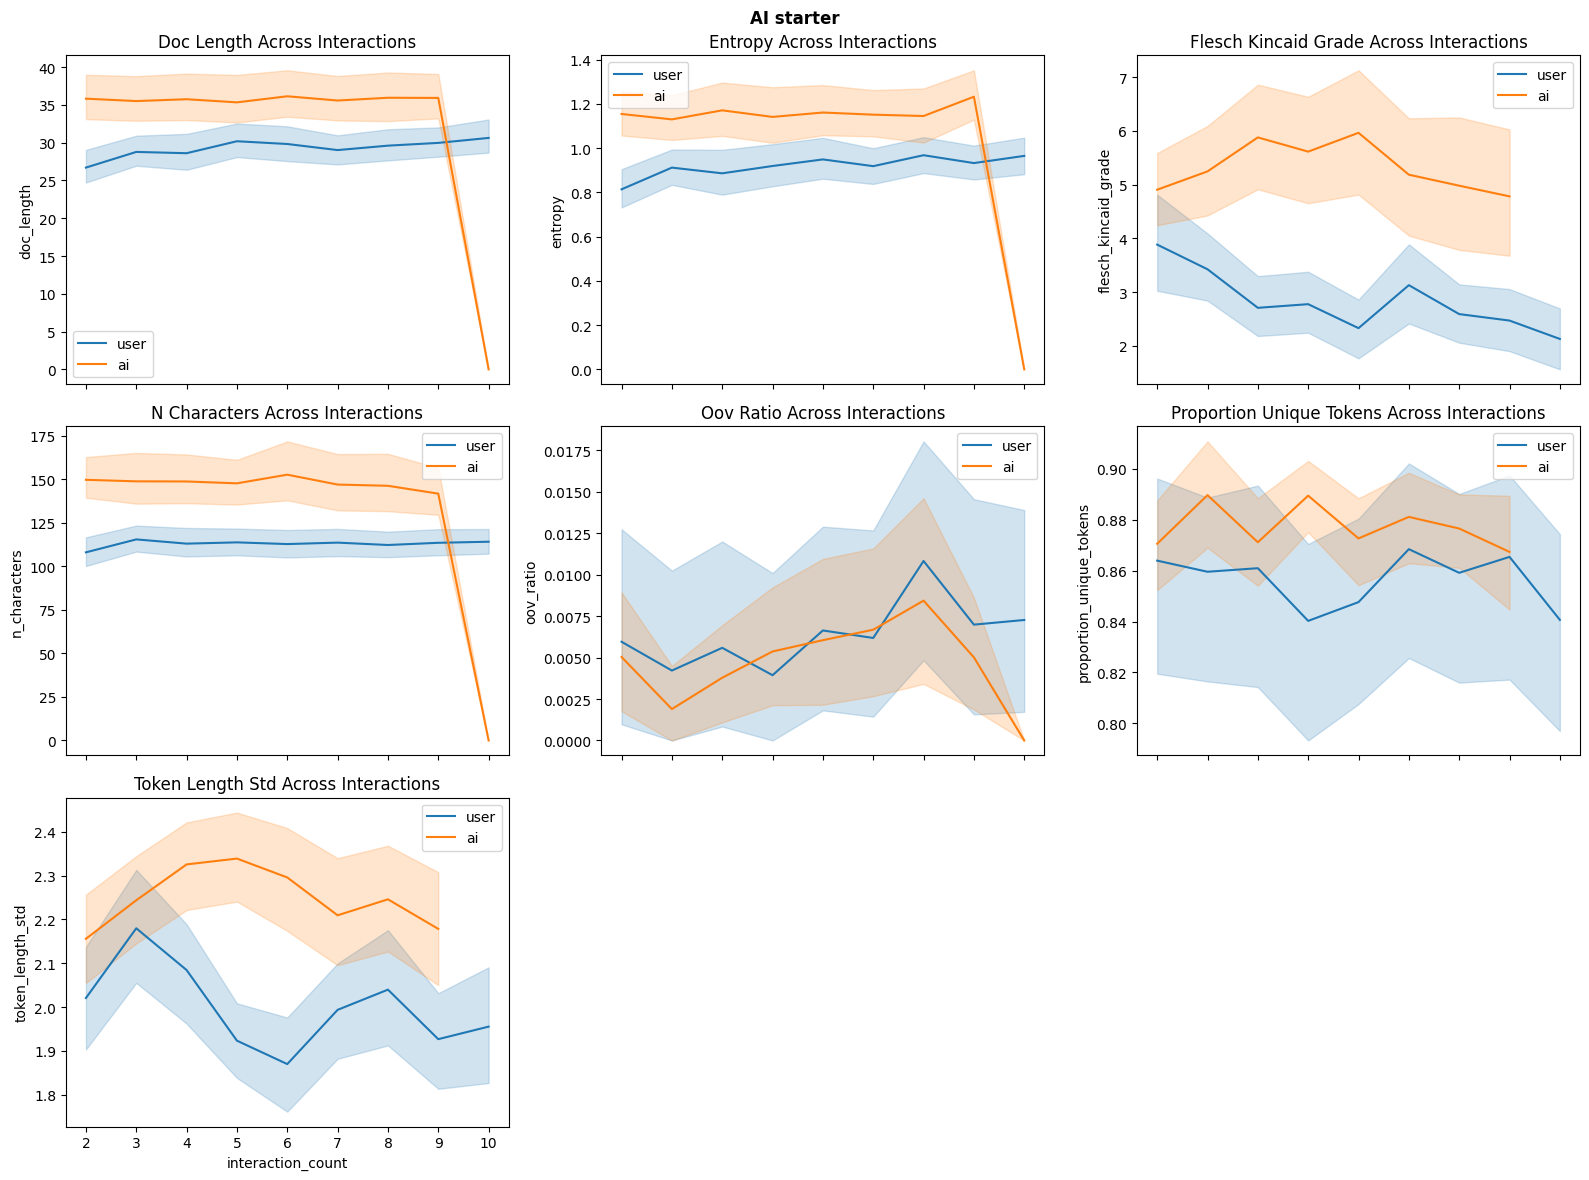

In [68]:
metrics = ['flesch_kincaid_grade', 'doc_length', 
'entropy', 
'n_characters', 
'oov_ratio', 
'proportion_unique_tokens', 
'token_length_std']

plot_interaction_descriptives(df=df_inter, metrics=metrics, starter='ai')

In [69]:
df_full

,text,flesch_reading_ease,flesch_kincaid_grade,smog,gunning_fog,automated_readability_index,coleman_liau_index,lix,rix,passed_quality_check,...,syllables_per_token_mean,syllables_per_token_median,syllables_per_token_std,n_tokens,n_unique_tokens,proportion_unique_tokens,n_characters,n_sentences,type,conversation_id
0,This is the story of\n\nThere once was a young...,85.741964,4.778036,7.865859,7.564286,6.533705,8.256964,31.857143,2.500000,True,...,1.263393,1.0,0.588050,224,124,0.553571,1020,16,user,conv_006cb479-ccd3-40d1-83fb-4b614573f636
1,"She looked at the dark sea, waiting for sign ...",95.377484,3.222911,5.683918,5.868365,4.396901,5.983270,25.317300,1.600000,True,...,1.159696,1.0,0.405723,263,153,0.581749,1108,20,user,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a
2,"This is the story of\n\nJohn Cena, the famous ...",89.817190,6.174462,6.574016,9.427537,7.895500,5.783402,32.697473,2.363636,True,...,1.120332,1.0,0.372890,241,156,0.647303,1018,11,user,conv_0bb56093-3033-4615-bb70-ebfa4135589a
3,This is the story of\n\na small town girl who ...,52.083529,15.044594,13.484332,18.179272,18.930521,11.034980,59.173669,8.285714,True,...,1.392157,1.0,0.851260,255,168,0.658824,1217,7,user,conv_0f18b30f-7d4b-4681-b98e-a0ff4f2b5256
4,"This is the story of\n\nA young girl, riding h...",91.770745,3.884841,6.836019,6.737164,5.311454,6.830229,30.201687,2.263158,True,...,1.194656,1.0,0.482806,262,158,0.603053,1164,19,user,conv_11293fd2-d757-471f-8e2e-783542167a8e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,depth and layers I hadn't considered before. T...,70.006829,7.621444,10.504224,10.657822,8.188699,9.025552,37.681345,3.500000,True,...,1.418060,1.0,0.802885,299,169,0.565217,1417,18,ai,conv_da1c7ee9-2479-4f47-94bc-db9161a6e88c
76,"to the diamond mine, their joyful voices echoi...",24.787274,27.999343,13.427900,31.074744,36.912440,10.908123,96.116894,16.750000,True,...,1.273038,1.0,0.572871,293,180,0.614334,1394,4,ai,conv_e335739c-0072-4945-8fe4-457a04c0997b
77,This is the story of a lighthouse keeper who s...,90.595634,3.034877,6.627428,5.428398,5.195283,8.330300,29.450823,1.916667,True,...,1.257511,1.0,0.534434,233,153,0.656652,1128,24,ai,conv_e73d720a-ff86-4c9b-b988-d6cc879215d9
78,"This is the story of a young girl named Ava, w...",10.879508,34.183173,13.023867,37.461747,44.019213,9.193210,106.569496,14.666667,True,...,1.232472,1.0,0.537708,271,156,0.575646,1208,3,ai,conv_f5028a6e-05a3-4757-84d0-491a6f400c24


## Modelling

In [155]:


def pivot_for_modelling(df, variable, inter=False, starter=None):
    if inter:
        idx = ['conversation_id', 'interaction_count']#, 'starter']
    else:
        idx = ['conversation_id']

    if starter: 
        df = df[df['starter'] == starter]

    df_pivot = (
        df.pivot_table(
            index=idx,
            columns='type',
            values=variable,
            aggfunc='mean'            # turn-level safety
        )
        .reset_index()
        .rename(columns={"ai": f"ai_{variable}", "user": f"user_{variable}"})
    )

    return df_pivot


In [134]:
vars = [col for col in df_full if col.startswith('pos_') and not col.endswith('X') and not col.endswith('SYM')]

#### Full story models

In [ ]:

for var in vars:
    df_story = pivot_for_modelling(df_full, variable=var, inter=False)

    print(f"\nStory-level model for {var}")
    model_story = smf.mixedlm(
        f"ai_{var} ~ user_{var} + starter",
        df_story,
        groups=df_story["conversation_id"]
    ).fit()
    print(model_story.summary())



Story-level model for pos_prop_ADJ
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_ADJ
No. Observations: 79      Method:             REML           
No. Groups:       79      Scale:              0.0002         
Min. group size:  1       Log-Likelihood:     191.0110       
Max. group size:  1       Converged:          Yes            
Mean group size:  1.0                                        
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.060    0.001 57.626 0.000  0.058  0.062
starter[T.user]    -0.004    0.004 -0.936 0.349 -0.013  0.005
user_pos_prop_ADJ   0.121    0.035  3.508 0.000  0.054  0.189
Group Var           0.000                                    


Story-level model for pos_prop_ADP
            Mixed Linear Model Regression Results
Model:            Mix

/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237


Story-level model for pos_prop_CCONJ
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_CCONJ
No. Observations: 79      Method:             REML             
No. Groups:       79      Scale:              0.0001           
Min. group size:  1       Log-Likelihood:     204.1099         
Max. group size:  1       Converged:          Yes              
Mean group size:  1.0                                          
---------------------------------------------------------------
                       Coef. Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept              0.024    0.005 5.293 0.000  0.015  0.033
starter[T.user]        0.002    0.003 0.677 0.498 -0.003  0.007
user_pos_prop_CCONJ    0.255    0.118 2.165 0.030  0.024  0.486
Group Var              0.000                                   


Story-level model for pos_prop_DET
            Mixed Linear Model Regression 

/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237


Story-level model for pos_prop_NOUN
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_NOUN
No. Observations: 79      Method:             REML            
No. Groups:       79      Scale:              0.0003          
Min. group size:  1       Log-Likelihood:     170.8131        
Max. group size:  1       Converged:          Yes             
Mean group size:  1.0                                         
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.154    0.006 27.531 0.000  0.143  0.165
starter[T.user]     -0.001    0.005 -0.145 0.884 -0.011  0.010
user_pos_prop_NOUN   0.244    0.013 18.928 0.000  0.219  0.269
Group Var            0.000                                    


Story-level model for pos_prop_NUM
            Mixed Linear Model Regression Results
Model: 

...

/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_PROPN
No. Observations: 79      Method:             REML             
No. Groups:       79      Scale:              0.0009           
Min. group size:  1       Log-Likelihood:     127.6489         
Max. group size:  1       Converged:          Yes              
Mean group size:  1.0                                          
---------------------------------------------------------------
                       Coef. Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept              0.008    0.001 8.235 0.000  0.006  0.010
starter[T.user]        0.012    0.007 1.736 0.083 -0.002  0.025
user_pos_prop_PROPN    0.504    0.056 8.987 0.000  0.394  0.614
Group Var              0.001                                   


Story-level model for pos_prop_PUNCT
             Mixed Linear Model Regression Results
Model:            MixedLM D

/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_VERB
No. Observations: 79      Method:             REML            
No. Groups:       79      Scale:              0.0002          
Min. group size:  1       Log-Likelihood:     192.5996        
Max. group size:  1       Converged:          Yes             
Mean group size:  1.0                                         
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.123    0.011 11.460 0.000  0.102  0.145
starter[T.user]     -0.000    0.003 -0.108 0.914 -0.007  0.006
user_pos_prop_VERB   0.072    0.068  1.068 0.286 -0.060  0.205
Group Var            0.000                                    



/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


#### Interaction level models

In [153]:
df_turn

type,conversation_id,interaction_count,ai_pos_prop_ADJ,user_pos_prop_ADJ
0,conv_006cb479-ccd3-40d1-83fb-4b614573f636,1.0,0.114286,0.033333
1,conv_006cb479-ccd3-40d1-83fb-4b614573f636,2.0,0.057143,0.137931
2,conv_006cb479-ccd3-40d1-83fb-4b614573f636,3.0,0.114286,0.107143
3,conv_006cb479-ccd3-40d1-83fb-4b614573f636,4.0,0.117647,0.066667
4,conv_006cb479-ccd3-40d1-83fb-4b614573f636,5.0,0.114286,0.105263
...,...,...,...,...
375,conv_e335739c-0072-4945-8fe4-457a04c0997b,6.0,0.058824,0.120000
376,conv_e335739c-0072-4945-8fe4-457a04c0997b,7.0,0.057143,0.068966
377,conv_e335739c-0072-4945-8fe4-457a04c0997b,8.0,0.205882,0.037037
378,conv_e335739c-0072-4945-8fe4-457a04c0997b,9.0,0.142857,0.142857


In [160]:
for var in vars:
    df_turn = pivot_for_modelling(df_inter, variable=var, inter=True, starter='user')
    df_turn = df_turn.dropna(subset=[f"ai_{var}", f"user_{var}"]).copy()

    print(f"\nTurn-level model for {var}")
    model_turn = smf.mixedlm(
        f"ai_{var} ~ user_{var}",
        df_turn,
        groups=df_turn["conversation_id"],
        # re_formula=f"~user_{var}"     # optional random slopes
    ).fit()
    print(model_turn.summary())



Turn-level model for pos_prop_ADJ


/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_ADJ
No. Observations: 377     Method:             REML           
No. Groups:       38      Scale:              0.0021         
Min. group size:  9       Log-Likelihood:     609.7863       
Max. group size:  10      Converged:          Yes            
Mean group size:  9.9                                        
-------------------------------------------------------------
                    Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.061    0.004 13.675 0.000  0.052  0.069
user_pos_prop_ADJ   0.040    0.052  0.765 0.444 -0.062  0.142
Group Var           0.000    0.002                           


Turn-level model for pos_prop_ADP


/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_ADP
No. Observations: 377     Method:             REML           
No. Groups:       38      Scale:              0.0016         
Min. group size:  9       Log-Likelihood:     659.8701       
Max. group size:  10      Converged:          Yes            
Mean group size:  9.9                                        
-------------------------------------------------------------
                    Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.093    0.006 16.681 0.000  0.082  0.104
user_pos_prop_ADP   0.053    0.046  1.155 0.248 -0.037  0.142
Group Var           0.000    0.003                           


Turn-level model for pos_prop_ADV


...

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_PUNCT
No. Observations: 377     Method:             REML             
No. Groups:       38      Scale:              0.0019           
Min. group size:  9       Log-Likelihood:     611.4738         
Max. group size:  10      Converged:          Yes              
Mean group size:  9.9                                          
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.118    0.007 18.117 0.000  0.106  0.131
user_pos_prop_PUNCT   0.159    0.044  3.589 0.000  0.072  0.246
Group Var             0.001    0.004                           


Turn-level model for pos_prop_SCONJ


/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_SCONJ
No. Observations: 377     Method:             REML             
No. Groups:       38      Scale:              0.0006           
Min. group size:  9       Log-Likelihood:     862.4701         
Max. group size:  10      Converged:          Yes              
Mean group size:  9.9                                          
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.019    0.002 10.516 0.000  0.016  0.023
user_pos_prop_SCONJ  -0.007    0.046 -0.161 0.872 -0.098  0.083
Group Var             0.000    0.001                           


Turn-level model for pos_prop_VERB


/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/work/PENPAL/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ai_pos_prop_VERB
No. Observations: 377     Method:             REML            
No. Groups:       38      Scale:              0.0020          
Min. group size:  9       Log-Likelihood:     614.1099        
Max. group size:  10      Converged:          No              
Mean group size:  9.9                                         
--------------------------------------------------------------
                     Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.122    0.007 17.572 0.000  0.109  0.136
user_pos_prop_VERB   0.086    0.047  1.833 0.067 -0.006  0.179
Group Var            0.000    0.003                           



In [158]:
df_turn.iloc[376:]

type,conversation_id,interaction_count,ai_pos_prop_ADJ,user_pos_prop_ADJ
376,conv_e335739c-0072-4945-8fe4-457a04c0997b,7.0,0.057143,0.068966
377,conv_e335739c-0072-4945-8fe4-457a04c0997b,8.0,0.205882,0.037037
378,conv_e335739c-0072-4945-8fe4-457a04c0997b,9.0,0.142857,0.142857
379,conv_e335739c-0072-4945-8fe4-457a04c0997b,10.0,0.028571,0.035714
